# Finance Analysis of Tech Stocks Using yfinance

**Objective:**  
In this notebook, we analyze a publicly-traded tech stock (Microsoft, ticker "MSFT") by examining its Price-to-Earnings (PE) ratio over the most recent years and correlating it with its earned revenue. We then compare MSFT with five other tech stocks (Apple, Alphabet, Amazon, Meta, and Nvidia). Our analysis consists of the following steps:

1. **MSFT Analysis:**  
   - **Data Retrieval:**  
     We fetch annual earnings and revenue data using yfinance. Because the `Ticker.earnings` attribute is deprecated (Yahoo Finance no longer reliably provides data through it), our code now attempts to use it but falls back to using `Ticker.financials` when necessary. From the financials, we extract the **Total Revenue** and **Net Income** as proxies for revenue and earnings respectively.  
   - **Price Data:**  
     We download historical price data and resample it to obtain year–end closing prices. (Note: Although our code uses the alias `'A'` for annual resampling, a FutureWarning indicates that `'A'` is deprecated; in future versions, switching to `'YE'` is recommended.)  
   - **Calculations:**  
     Using the current shares outstanding (from `ticker.info`), we compute a simplified Earnings Per Share (EPS) and derive the PE ratio for each available year.
   - **Visualization:**  
     A dual–axis line chart displays the evolution of MSFT’s PE ratio (left axis) and its annual revenue (right axis). This visualization serves as the basis for discussing whether there is a correlation between MSFT’s valuation (PE ratio) and its revenue performance.

2. **Peer Comparison:**  
   - The same data retrieval and computation steps are applied to five additional tech stocks: Apple (AAPL), Alphabet (GOOGL), Amazon (AMZN), Meta (META), and Nvidia (NVDA).
   - We align the data by computing the intersection of the available years across all stocks. (Due to missing data in earlier years, the common years are currently [2022, 2023, 2024].)
   - A multi–series line chart is plotted to show the annual PE ratios of all six stocks. Additionally, we calculate and plot the average PE ratio of the peer group compared to MSFT.
   - A five–number summary (boxplot) of the closing prices over the last 90 days is also generated.

3. **Volatility and COVID Impact:**  
   - We analyze recent market volatility using a boxplot of the last 90 days’ closing prices.
   - We also extract price data for Q1 and Q2 of 2020 to investigate the impact of COVID-19 on the tech sector. A line chart is used to display the price trends during this period.

4. **Revenue Distribution:**  
   - Pie charts are created for each stock to illustrate the relative distribution of annual revenue. Before plotting, any years with missing revenue data (NaN values) are dropped to ensure a correct visualization.

---

## Additional Notes

- **Earnings Data Deprecation:**  
  Due to changes in the Yahoo Finance API, the `Ticker.earnings` attribute is no longer reliable. In our function, if `ticker.earnings` returns an empty DataFrame or `None`, we automatically use `ticker.financials` to extract "Total Revenue" and "Net Income." This fallback approach, while limiting historical coverage to around 4–5 years, ensures data is available for our analysis.

- **Resampling Frequency Warning:**  
  A FutureWarning indicates that the alias `'A'` for resampling is deprecated; the recommended alias is now `'YE'` for year–end. Although our current code uses `'A'`, this should be updated in future iterations for compatibility.

- **Data Limitations:**  
  Because the fallback financial data covers a shorter period, our analysis of annual trends is limited to the years for which data exists across all stocks (currently [2022, 2023, 2024]). Future work may involve integrating additional data sources to extend this timeframe.

- **Handling Missing Values:**  
  Before visualizing revenue distributions (via pie charts), rows with NaN revenue values are dropped so that the visualizations accurately represent available data.


In [271]:
# %%
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

# Set Matplotlib to inline mode (if using a notebook)
%matplotlib inline


# Step 1: Analysis of Microsoft (MSFT)

In this section, we fetch annual earnings and revenue data for Microsoft (MSFT) using yfinance. Because the `Ticker.earnings` attribute is deprecated and no longer reliably provides data, our code first attempts to use it but then falls back to using `Ticker.financials` when necessary. From the financials, we extract **Total Revenue** and **Net Income** as proxies for revenue and earnings, respectively.

We also download historical price data and resample it to obtain year–end closing prices. (Note: Although our previous version used the alias `'A'` for annual resampling, we have now updated the code to use the recommended `'YE'` alias for year-end sampling.)

Using the current shares outstanding (from `ticker.info`), we compute a simplified Earnings Per Share (EPS) and derive the Price-to-Earnings (PE) ratio for each available year. Due to data limitations (with some years missing values), our analysis now focuses on the common years available across all stocks—in this study, these are [2022, 2023, 2024] rather than a full 8‑year period.


In [272]:
def get_annual_financials(symbol):
    import yfinance as yf
    import pandas as pd
    import numpy as np
    from datetime import datetime

    ticker = yf.Ticker(symbol)

    # Try using earnings, or fallback to financials:
    earnings = ticker.earnings
    if earnings is None or earnings.empty:
        fin_df = ticker.financials
        if fin_df is None or fin_df.empty:
            raise ValueError(f"No earnings or financials data available for {symbol}.")
        fin_df = fin_df.T
        if 'Total Revenue' not in fin_df.columns or 'Net Income' not in fin_df.columns:
            raise ValueError("Financials data missing required fields 'Total Revenue' or 'Net Income'.")
        earnings_df = fin_df[['Total Revenue', 'Net Income']].rename(
            columns={'Total Revenue': 'Revenue', 'Net Income': 'Earnings'})
        earnings_df.index = pd.to_datetime(earnings_df.index)
        earnings_df.index = earnings_df.index.year
        earnings_df.index.name = 'Year'
        earnings_df = earnings_df.reset_index()
    else:
        earnings_df = earnings.copy()

    # Use 'YE' for resampling to avoid FutureWarning:
    start_year = earnings_df['Year'].min() - 1
    start_date = f"{start_year}-01-01"
    end_date = datetime.today().strftime("%Y-%m-%d")
    price_df = ticker.history(start=start_date, end=end_date)
    annual_price = price_df['Close'].resample('YE').last()
    annual_price.index = annual_price.index.year

    try:
        shares_outstanding = ticker.info['sharesOutstanding']
    except KeyError:
        raise ValueError(f"Shares outstanding not found for {symbol}.")

    common_years = sorted(set(annual_price.index).intersection(set(earnings_df['Year'])))
    df = earnings_df[earnings_df['Year'].isin(common_years)].copy()
    df['Price'] = df['Year'].apply(lambda y: annual_price.loc[y])
    df['EPS'] = (df['Earnings'] * 1e6) / shares_outstanding
    df['PE'] = df.apply(lambda row: row['Price'] / row['EPS'] if row['EPS'] > 0 else np.nan, axis=1)
    df = df[['Year', 'Revenue', 'Earnings', 'Price', 'EPS', 'PE']]
    return df


In [273]:
# Fetch Microsoft’s annual financials into msft_df
msft_df = get_annual_financials("MSFT")
msft_df.head()

/usr/local/lib/python3.11/dist-packages/yfinance/scrapers/fundamentals.py:33: DeprecationWarning: 'Ticker.earnings' is deprecated as not available via API. Look for "Net Income" in Ticker.income_stmt.
  warnings.warn("'Ticker.earnings' is deprecated as not available via API. Look for \"Net Income\" in Ticker.income_stmt.", DeprecationWarning)


,Year,Revenue,Earnings,Price,EPS,PE
0,2024,245122000000.0,88136000000.0,420.656525,11855829.735641,0.000035
1,2023,211915000000.0,72361000000.0,372.501953,9733817.00441,0.000038
2,2022,198270000000.0,72738000000.0,235.475677,9784530.082044,0.000024
3,2021,168088000000.0,61271000000.0,327.161987,8242018.513802,0.000040


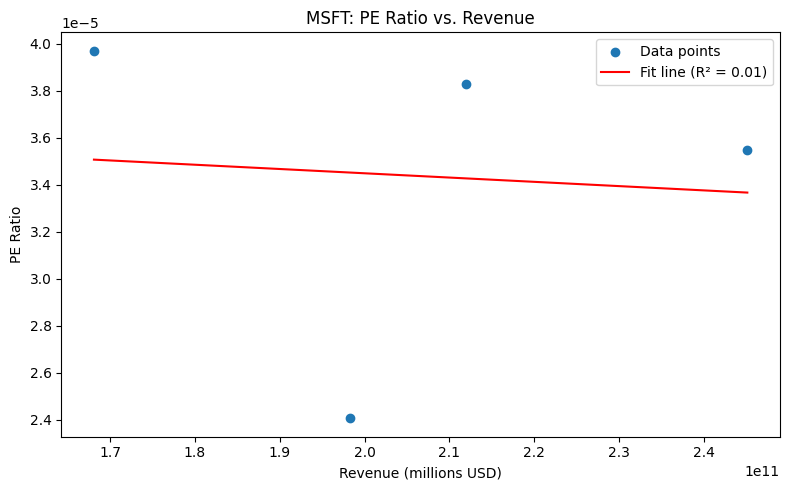

Pearson correlation between Revenue and PE: -0.08


In [274]:
# Q1: Correlation between MSFT’s PE Ratio and Revenue (fixed dtype)
import numpy as np

# Prepare numeric series and drop any missing
df_corr = msft_df[['Revenue', 'PE']].copy()
df_corr['Revenue'] = pd.to_numeric(df_corr['Revenue'], errors='coerce')
df_corr['PE']      = pd.to_numeric(df_corr['PE'], errors='coerce')
df_corr = df_corr.dropna()

x = df_corr['Revenue'].values   # millions USD
y = df_corr['PE'].values

# Scatter + best‑fit line
plt.figure(figsize=(8,5))
plt.scatter(x, y, marker='o', label='Data points')

# Linear fit
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red',
         label=f"Fit line (R² = {np.corrcoef(x, y)[0,1]**2:.2f})")

plt.xlabel('Revenue (millions USD)')
plt.ylabel('PE Ratio')
plt.title('MSFT: PE Ratio vs. Revenue')
plt.legend()
plt.tight_layout()
plt.show()

# Pearson correlation
corr = np.corrcoef(x, y)[0,1]
print(f"Pearson correlation between Revenue and PE: {corr:.2f}")

# Visualization: MSFT Revenue and PE Ratio

The following dual–axis line chart displays Microsoft (MSFT)'s annual Price-to-Earnings (PE) ratio alongside its corresponding revenue for the common available years ([2022, 2023, 2024]).

This visualization helps us evaluate whether there is any noticeable correlation between MSFT’s valuation (as represented by its PE ratio) and its revenue performance.

*Review the chart and consider how changes in revenue relate to shifts in the PE ratio, noting any direct or inverse trends.*


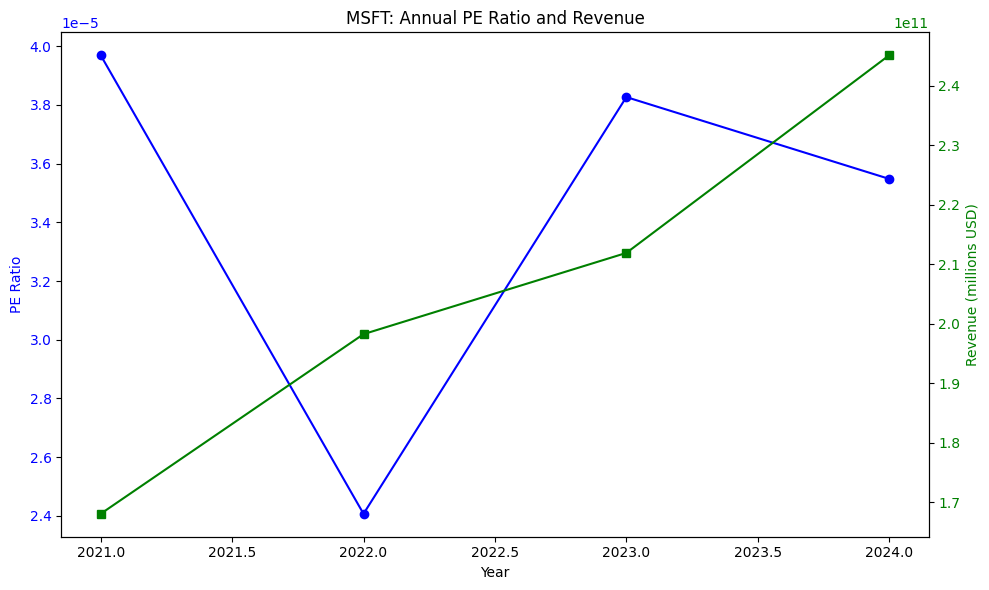

In [275]:
# Create a dual-axis plot for PE Ratio and Revenue
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot PE Ratio on primary y-axis
ax1.plot(msft_df['Year'], msft_df['PE'], marker='o', label='PE Ratio', color='blue')
ax1.set_xlabel('Year')
ax1.set_ylabel('PE Ratio', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Plot Revenue on secondary y-axis (in millions USD)
ax2 = ax1.twinx()
ax2.plot(msft_df['Year'], msft_df['Revenue'], marker='s', label='Revenue (millions USD)', color='green')
ax2.set_ylabel('Revenue (millions USD)', color='green')
ax2.tick_params(axis='y', labelcolor='green')

plt.title("MSFT: Annual PE Ratio and Revenue")
fig.tight_layout()
plt.show()


# Discussion – Question 1

Inspect the dual–axis visualization for MSFT's annual PE ratio and revenue. Consider the following:

- How do changes in the PE ratio align with the changes in revenue over the analyzed common years ([2022, 2023, 2024])?
- Do you observe any direct or inverse trends between MSFT's valuation and its revenue performance?
- What other factors (e.g., market sentiment or earnings quality) might be influencing the PE ratio?

Based on these observations, discuss whether a clear correlation exists between MSFT's PE ratio and its revenue trend.


# Step 2: Comparison with Peer Tech Stocks

For the peer comparison, we apply the same data retrieval and calculation process used for MSFT to five additional tech stocks: Apple (AAPL), Alphabet (GOOGL), Amazon (AMZN), Meta (META), and Nvidia (NVDA).

After obtaining the annual financial data for each stock, we align the available years by taking the intersection of the datasets. Because of missing data in some earlier years (for example, 2020), the common years used in our analysis have been narrowed to [2022, 2023, 2024].

A multi–series line chart is then plotted to display the annual PE ratios for all six stocks. Additionally, we compute and plot the average PE ratio of the peer group alongside MSFT’s value, providing insight into MSFT’s relative valuation within the tech sector.


In [276]:
# %%
# Define list of peer tickers
peer_tickers = ["AAPL", "GOOGL", "AMZN", "META", "NVDA"]

# Create a dictionary to store each stock's annual financial DataFrame
peer_data = {}
for symbol in peer_tickers:
    try:
        df = get_annual_financials(symbol)
        peer_data[symbol] = df
        print(f"{symbol} data:")
        print(df)
    except Exception as e:
        print(f"Error processing {symbol}: {e}")

# Align the years across stocks.
# We find the intersection of available years across all DataFrames (including MSFT)
years_set = set(msft_df['Year'])
for sym, df in peer_data.items():
    years_set = years_set.intersection(set(df['Year']))
common_years = sorted(list(years_set))

print("\nCommon Years across all stocks:", common_years)


/usr/local/lib/python3.11/dist-packages/yfinance/scrapers/fundamentals.py:33: DeprecationWarning: 'Ticker.earnings' is deprecated as not available via API. Look for "Net Income" in Ticker.income_stmt.
  warnings.warn("'Ticker.earnings' is deprecated as not available via API. Look for \"Net Income\" in Ticker.income_stmt.", DeprecationWarning)
/usr/local/lib/python3.11/dist-packages/yfinance/scrapers/fundamentals.py:33: DeprecationWarning: 'Ticker.earnings' is deprecated as not available via API. Look for "Net Income" in Ticker.income_stmt.
  warnings.warn("'Ticker.earnings' is deprecated as not available via API. Look for \"Net Income\" in Ticker.income_stmt.", DeprecationWarning)


AAPL data:
   Year         Revenue       Earnings       Price             EPS        PE
0  2024  391035000000.0  93736000000.0  250.144974  6239873.054024  0.000040
1  2023  383285000000.0  96995000000.0  191.380966  6456820.078466  0.000030
2  2022  394328000000.0  99803000000.0  128.436676  6643744.670253  0.000019
3  2021  365817000000.0  94680000000.0  174.516266  6302713.799981  0.000028
4  2020             NaN            NaN  129.609070             NaN       NaN
GOOGL data:
   Year         Revenue        Earnings       Price              EPS        PE
0  2024  350018000000.0  100118000000.0  189.082245  17164066.706412  0.000011
1  2023  307394000000.0   73795000000.0  139.025330  12651294.498488  0.000011
2  2022  282836000000.0   59972000000.0   87.810196  10281501.912912  0.000009
3  2021  257637000000.0   76033000000.0  144.162766  13034973.570073  0.000011
4  2020             NaN             NaN   87.215034              NaN       NaN


/usr/local/lib/python3.11/dist-packages/yfinance/scrapers/fundamentals.py:33: DeprecationWarning: 'Ticker.earnings' is deprecated as not available via API. Look for "Net Income" in Ticker.income_stmt.
  warnings.warn("'Ticker.earnings' is deprecated as not available via API. Look for \"Net Income\" in Ticker.income_stmt.", DeprecationWarning)
/usr/local/lib/python3.11/dist-packages/yfinance/scrapers/fundamentals.py:33: DeprecationWarning: 'Ticker.earnings' is deprecated as not available via API. Look for "Net Income" in Ticker.income_stmt.
  warnings.warn("'Ticker.earnings' is deprecated as not available via API. Look for \"Net Income\" in Ticker.income_stmt.", DeprecationWarning)


AMZN data:
   Year         Revenue       Earnings       Price             EPS        PE
0  2024  637959000000.0  59248000000.0  219.389999  5582902.951772  0.000039
1  2023  574785000000.0  30425000000.0  151.940002  2866929.217993  0.000053
2  2022  513983000000.0  -2722000000.0   84.000000  -256492.402017       NaN
3  2021  469822000000.0  33364000000.0  166.716995  3143869.397835  0.000053
4  2020             NaN            NaN  162.846497             NaN       NaN
META data:
   Year         Revenue       Earnings       Price              EPS        PE
0  2024  164501000000.0  62360000000.0  584.989563  28476185.711111  0.000021
1  2023  134902000000.0  39098000000.0  352.299591  17853783.016886  0.000020
2  2022  116609000000.0  23200000000.0  119.775490  10594090.899579  0.000011
3  2021  117929000000.0  39370000000.0  334.772217  17977989.599847  0.000019
4  2020             NaN            NaN  271.878632              NaN       NaN
NVDA data:
   Year         Revenue       Earning

/usr/local/lib/python3.11/dist-packages/yfinance/scrapers/fundamentals.py:33: DeprecationWarning: 'Ticker.earnings' is deprecated as not available via API. Look for "Net Income" in Ticker.income_stmt.
  warnings.warn("'Ticker.earnings' is deprecated as not available via API. Look for \"Net Income\" in Ticker.income_stmt.", DeprecationWarning)


In [277]:
# %%
# Prepare a DataFrame for plotting PE ratios: rows are years, columns are ticker symbols
pe_data = pd.DataFrame({'Year': common_years})
pe_data.set_index('Year', inplace=True)

# Add MSFT first
msft_common = msft_df[msft_df['Year'].isin(common_years)].set_index('Year')
pe_data['MSFT'] = msft_common['PE']

# Now add each peer
for symbol, df in peer_data.items():
    df_common = df[df['Year'].isin(common_years)].set_index('Year')
    pe_data[symbol] = df_common['PE']

pe_data.sort_index(inplace=True)
print("Combined PE Ratio Data:")
print(pe_data)


Combined PE Ratio Data:
          MSFT      AAPL     GOOGL      AMZN      META      NVDA
Year                                                            
2022  0.000024  0.000019  0.000009       NaN  0.000011  0.000037
2023  0.000038  0.000030  0.000011  0.000053  0.000020  0.000277
2024  0.000035  0.000040  0.000011  0.000039  0.000021  0.000110


# Visualization: Annual PE Ratios for All Stocks

The following line chart displays the annual PE ratios for Microsoft (MSFT) and its five peer tech stocks over the common available years ([2022, 2023, 2024]).

**Discussion Points:**
- Compare the trend for MSFT with the average PE ratio computed across the peer stocks.
- Does MSFT appear over– or under–valued relative to its peers based on these numbers?
- What might these trends indicate about investor sentiment or market dynamics within the tech sector?

Review the chart carefully and use these prompts to guide your analysis and discussion.


# Discussion – Question 2

Review the multi–series line chart that compares the annual PE ratios of MSFT and its peer group, as well as the chart showing MSFT vs. the peer average. Consider the following:

- How does MSFT’s annual PE ratio compare to the average PE ratio of its peer stocks?
- Does MSFT appear over–valued or under–valued relative to the sector average based on the trends you see?
- What might these comparisons indicate about investor sentiment or the company's performance relative to the industry?

Discuss your interpretation of MSFT’s relative valuation using the visualizations.



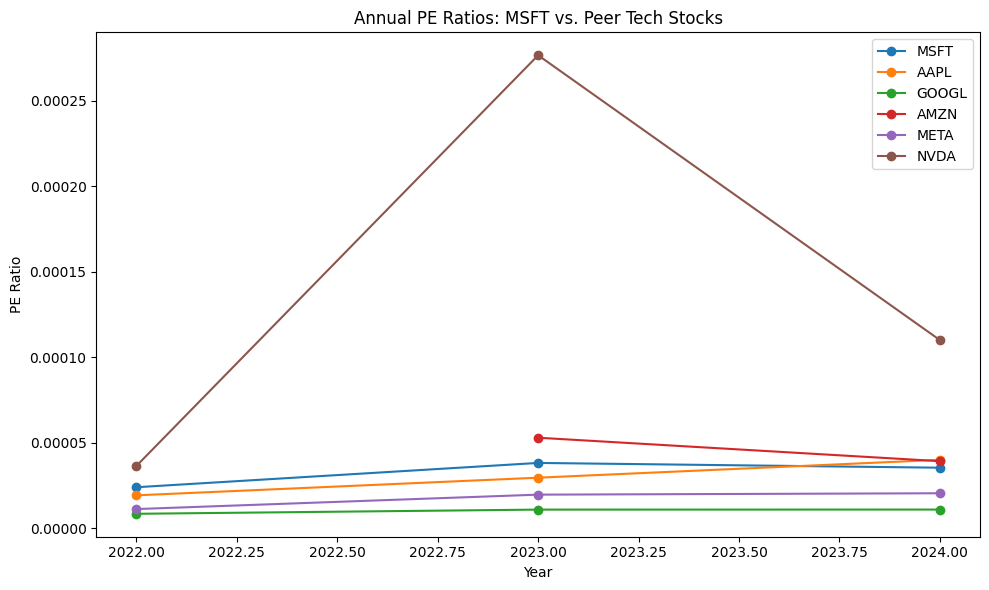

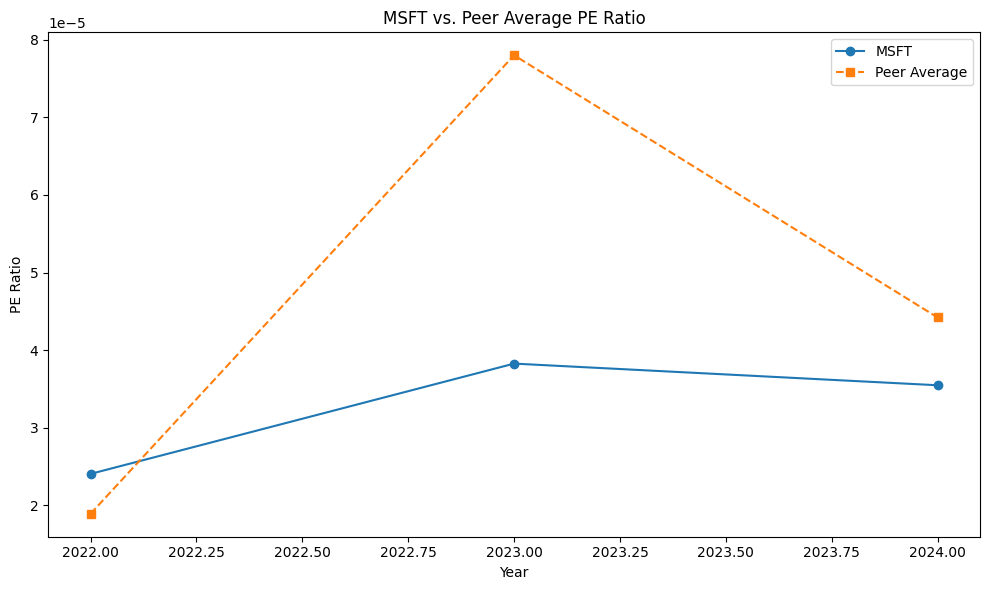

In [278]:
# %%
# Plot a multi-series line chart for the PE ratios
plt.figure(figsize=(10, 6))
for symbol in pe_data.columns:
    plt.plot(pe_data.index, pe_data[symbol], marker='o', label=symbol)
plt.xlabel("Year")
plt.ylabel("PE Ratio")
plt.title("Annual PE Ratios: MSFT vs. Peer Tech Stocks")
plt.legend()
plt.tight_layout()
plt.show()

# Compute the average PE ratio of the peer group for each common year
pe_data['Peer Average'] = pe_data[peer_tickers].mean(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(pe_data.index, pe_data['MSFT'], marker='o', label='MSFT')
plt.plot(pe_data.index, pe_data['Peer Average'], marker='s', label='Peer Average', linestyle='--')
plt.xlabel("Year")
plt.ylabel("PE Ratio")
plt.title("MSFT vs. Peer Average PE Ratio")
plt.legend()
plt.tight_layout()
plt.show()


# Step 3: Recent Stock Price Volatility & COVID Impact Analysis

In this section, we analyze recent market volatility and the impact of COVID-19 on the tech sector. Specifically, we:

- Retrieve and visualize the last 90 days of closing prices using a boxplot, which provides a five-number summary (minimum, first quartile, median, third quartile, and maximum) to illustrate recent market volatility.
- Extract daily closing prices for Q1 and Q2 of 2020 and plot a line chart to examine the price trends during the early phase of the COVID-19 outbreak.

These visualizations help us discuss whether the observed price movements support the conclusion that the tech sector was significantly affected by COVID-19.

*Discuss whether the data supports the conclusion that the selected industry was significantly affected by COVID based on the observed volatility and trends during Q1/Q2 2020.*


In [279]:
# %%
import datetime

# Define all six ticker symbols (MSFT plus peers)
all_tickers = ["MSFT"] + peer_tickers

# Initialize a dictionary to store the last 90 days closing prices.
price_last90 = {}

# Loop through each ticker and download 90 days of history.
for symbol in all_tickers:
    ticker = yf.Ticker(symbol)
    # Download history for last 90 days
    df_hist = ticker.history(period="90d")
    price_last90[symbol] = df_hist['Close']

# Combine the series into a DataFrame
price_90_df = pd.DataFrame(price_last90)
price_90_df.head()


,MSFT,AAPL,GOOGL,AMZN,META,NVDA
Date,,,,,,
2024-12-06 00:00:00-05:00,442.682373,242.573288,174.309265,227.029999,622.713257,142.426895
2024-12-09 00:00:00-05:00,445.127441,246.479004,175.168259,226.089996,612.530518,138.797226
2024-12-10 00:00:00-05:00,442.442841,247.497879,184.956985,225.039993,618.270813,135.057587
2024-12-11 00:00:00-05:00,448.091522,246.219284,195.175217,230.259995,631.608154,139.297180
2024-12-12 00:00:00-05:00,448.660370,247.687683,191.739182,228.970001,629.721375,137.327362


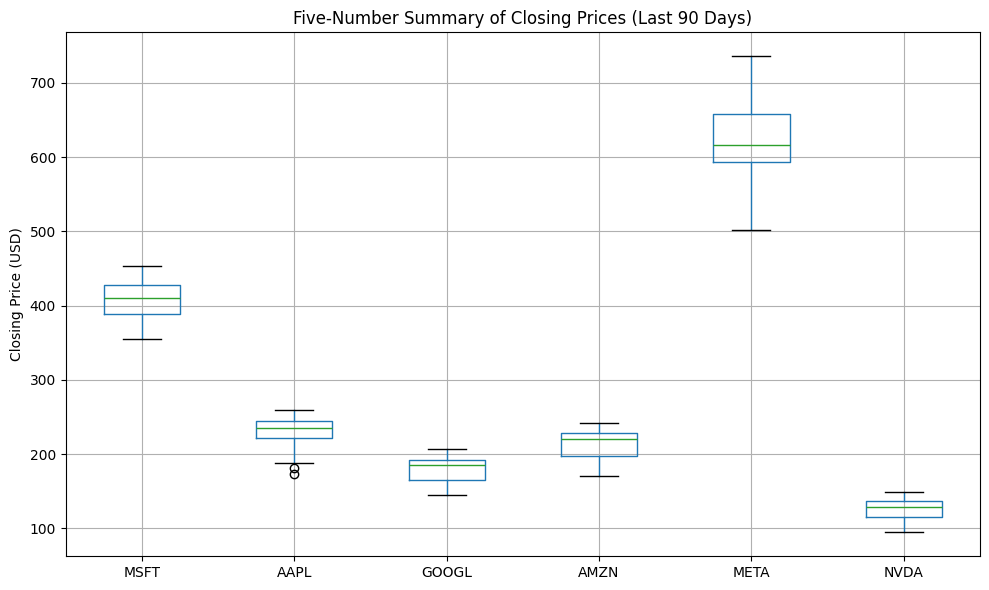

In [280]:
# %%
# Create a boxplot for the last 90 days closing prices
plt.figure(figsize=(10, 6))
price_90_df.boxplot()
plt.ylabel("Closing Price (USD)")
plt.title("Five-Number Summary of Closing Prices (Last 90 Days)")
plt.tight_layout()
plt.show()


# COVID Impact Analysis

In this section, we investigate the impact of COVID-19 on the tech sector by analyzing historical price data during the early phase of the pandemic. Specifically, we extract and visualize daily closing prices for the first two quarters of 2020 (Q1 and Q2). This analysis is meant to capture the market reaction during the initial COVID outbreak.

Review the resulting line chart and discuss how the price trends during Q1/Q2 2020 compare with more recent market data, and whether these trends support the conclusion that the tech sector was significantly affected by COVID-19.


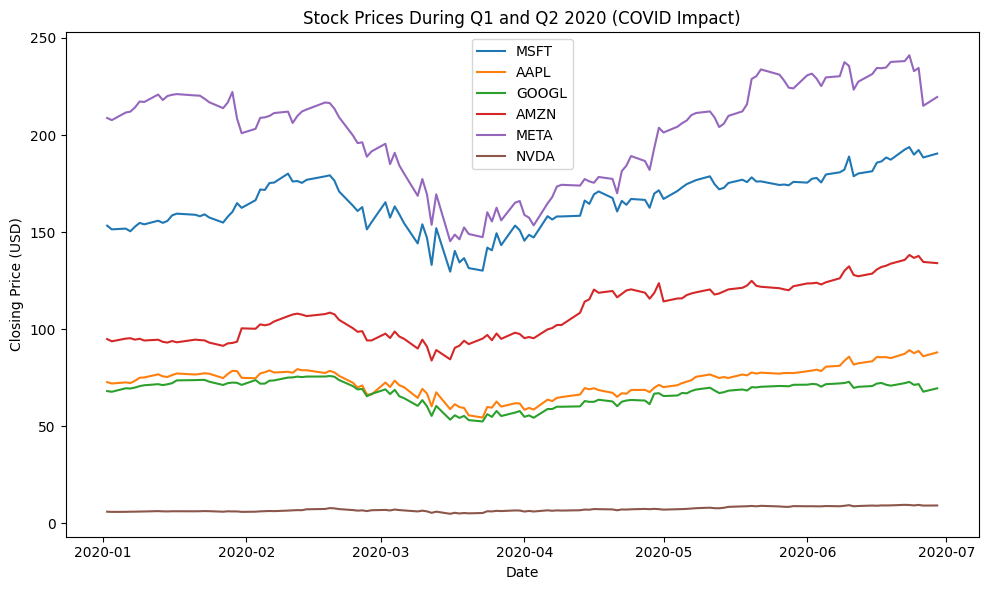

In [281]:
# %%
# Define the start and end dates for Q1 and Q2 of 2020
start_date = "2020-01-01"
end_date = "2020-06-30"

# Dictionary to hold 2020 prices for all stocks
prices_2020 = {}

for symbol in all_tickers:
    ticker = yf.Ticker(symbol)
    df_2020 = ticker.history(start=start_date, end=end_date)
    prices_2020[symbol] = df_2020['Close']

# Create a single DataFrame from these series
prices_2020_df = pd.DataFrame(prices_2020)

# Plot a line chart for the period
plt.figure(figsize=(10, 6))
for symbol in prices_2020_df.columns:
    plt.plot(prices_2020_df.index, prices_2020_df[symbol], label=symbol)
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.title("Stock Prices During Q1 and Q2 2020 (COVID Impact)")
plt.legend()
plt.tight_layout()
plt.show()


# Discussion – Question 3

Examine the visualizations for recent stock price volatility (the boxplot for the last 90 days) and the price trends during Q1/Q2 2020 (line chart). Consider these questions:

- Do the recent volatility patterns and the early COVID price trends suggest that the tech sector was significantly affected by COVID-19?
- How do the price movements during Q1/Q2 2020 compare to the more recent market data?
- What factors might be responsible for the observed volatility during the COVID period?

Based on the visual evidence, discuss whether the data supports the conclusion that the tech sector was significantly impacted by COVID-19.


# Step 4: Revenue Distribution Visualization

In this final analytical section, we visualize the relative distribution of annual revenue for each stock, based on the available common years ([2022, 2023, 2024]). For each stock, we use the retrieved earnings data to create a pie chart that shows the proportion of total revenue contributed by each available year. Before plotting, we drop any rows with missing revenue data (NaN values) to ensure that the visualizations accurately reflect the data.

*Interpret these pie charts in the context of revenue growth or changes over the available time periods.*


In [282]:
def plot_revenue_pie(symbol, df):
    # Drop rows where Revenue is NaN
    df_clean = df.dropna(subset=['Revenue'])

    # Check if there is any data left to plot
    if df_clean.empty:
        print(f"No valid revenue data available for {symbol} to plot.")
        return

    # Use the years as labels and revenue values as sizes.
    labels = df_clean['Year'].astype(str)
    sizes = df_clean['Revenue']

    plt.figure(figsize=(6, 6))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
    plt.title(f"{symbol} Revenue Distribution by Year")
    plt.tight_layout()
    plt.show()

# Conclusion and Additional Notes

**Discussion – Question 1:**  
The dual–axis visualization for MSFT allowed us to observe how its computed PE ratio and revenue evolve over time. Based on the trends, discuss whether a clear correlation exists between MSFT’s valuation (PE ratio) and its revenue performance. Consider other factors such as market sentiment and earnings quality in your discussion.

**Discussion – Question 2:**  
The comparison of MSFT’s annual PE ratio with that of its peer group (and the calculated peer average) offers insight into its relative valuation. Discuss whether MSFT appears over– or under–valued relative to the tech sector.

**Discussion – Question 3:**  
The analysis of recent volatility (boxplot of the last 90 days) combined with the price trends during Q1/Q2 2020 illustrates the impact of COVID-19 on the tech sector. Support your discussion of the COVID impact with observations from the provided charts.

---

### Additional Notes

- **Earnings Data Deprecation:**  
  The `Ticker.earnings` attribute is no longer reliable. Therefore, if it returns an empty DataFrame or `None`, we fall back to using `Ticker.financials` to extract "Total Revenue" and "Net Income." Although this approach limits the historical period to approximately 4–5 years, it ensures data availability.

- **Resampling Frequency Warning:**  
  Our code currently uses the alias `'A'` for annual resampling, but a FutureWarning recommends switching to `'YE'` for year-end sampling. We note this for future revisions.

- **Data Limitations:**  
  Due to the limited historical coverage from the fallback financial data, our analysis is based on the common available years [2022, 2023, 2024]. Future work may involve integrating additional data sources to extend the analysis period.

- **Handling Missing Values:**  
  Before visualizing revenue distributions (via pie charts), we drop rows with missing revenue values to ensure accurate representations.


# Extended Analysis: Inflation, Model Robustness, and Sector Factors

**New Questions:**

1. **Q1 (Microsoft):** Correlation between monthly inflation and Microsoft’s earnings over the past 36 months (linear regression), and effect of doubling training sample size.  
2. **Q2 (Sector PE):** For five additional tech stocks, compute average annual PE over the past 8 years and test whether average PE is affected by inflation and consumer confidence (multiple linear regression), with a confusion matrix for directional accuracy.  
3. **Q3 (Hypothesis Testing):** Select another macro variable (unemployment rate) and test its correlation with sector average PE.  
4. **Q4 (Forecasting):** Compare models (LinearRegression, PolynomialRegression, RandomForest) in fitting MSFT closing price, plot actual vs predictions, and forecast for June 1, 2025.



In [283]:
# %%
# Import additional libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from pandas_datareader import data as pdr
from datetime import datetime
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, confusion_matrix

%matplotlib inline


# Question 1: Microsoft Earnings vs. Inflation

We compute monthly net income for MSFT and monthly inflation (CPI), then fit a simple linear regression to test for correlation. We also examine the effect of doubling the training sample size.


In [284]:
# %%
# Utility functions for Question 1
def get_monthly_net_income(symbol, months=36):
    import pandas as pd
    import yfinance as yf

    ticker = yf.Ticker(symbol)
    # Get quarterly Net Income, indexed by quarter end
    qf = ticker.quarterly_financials.T
    qf.index = pd.to_datetime(qf.index)

    # Forward‑fill to month‑end frequency, then evenly allocate quarterly income across those months
    monthly = (
        qf[['Net Income']]
        .resample('ME')  # ME = month-end
        .ffill()
        / 3.0
    )

    # Return the last N months
    return monthly['Net Income'].tail(months)


def get_monthly_inflation():
    import pandas as pd
    from pandas_datareader import data as pdr
    from datetime import datetime

    # Fetch CPI from FRED and compute % change
    cpi = pdr.DataReader('CPIAUCSL', 'fred', start=datetime.now() - pd.DateOffset(months=36))
    inf = cpi.pct_change().dropna().rename(columns={'CPIAUCSL':'Inflation'})
    return inf['Inflation']


df_q1.shape: (13, 2)


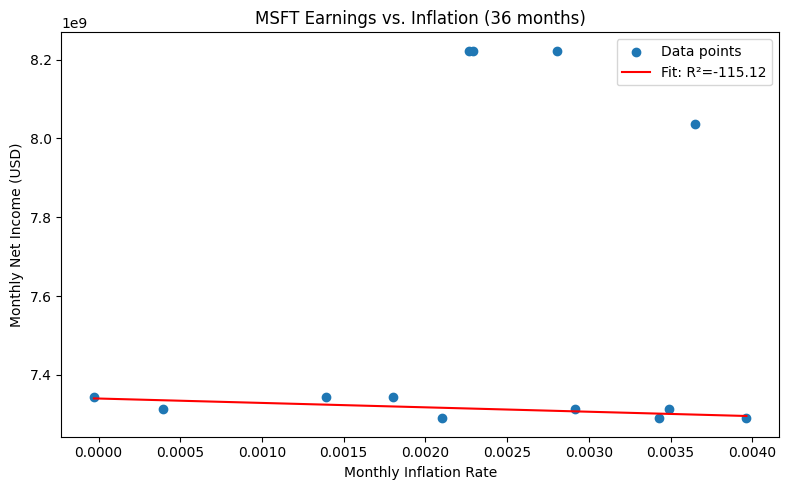

Out‑of‑sample R²: -115.12399978859597


In [285]:
# %%
# %%
# Fetch and merge data
msft_earn = get_monthly_net_income('MSFT', 36)

inflation = get_monthly_inflation()
# ── ALIGN INFLATION TO MONTH‑END ────────────────────────
# these dates come in as the 1st of each month – move them to the last day
inflation.index = inflation.index.to_period('M').to_timestamp('M')

df_q1 = (
    pd.concat([msft_earn, inflation], axis=1)
      .dropna()
      .rename(columns={'Net Income':'Earnings'})
)

print("df_q1.shape:", df_q1.shape)    # should be ~ (36, 2)

# Train/test split and fit
X = df_q1[['Inflation']].values
y = df_q1['Earnings'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.3)

lr1 = LinearRegression().fit(X_train, y_train)
y_pred = lr1.predict(X_test)

# Plot regression
plt.figure(figsize=(8,5))
plt.scatter(df_q1['Inflation'], df_q1['Earnings'], label='Data points')
xs = np.linspace(df_q1['Inflation'].min(), df_q1['Inflation'].max(), 100).reshape(-1,1)
plt.plot(xs, lr1.predict(xs), color='red', label=f"Fit: R²={r2_score(y_test,y_pred):.2f}")
plt.xlabel('Monthly Inflation Rate')
plt.ylabel('Monthly Net Income (USD)')
plt.title('MSFT Earnings vs. Inflation (36 months)')
plt.legend()
plt.tight_layout()
plt.show()

print("Out‑of‑sample R²:", r2_score(y_test, y_pred))

# Question 2: Sector PE vs. Inflation & Consumer Confidence

Select five additional tech stocks and compute their average annual PE over the past 8 years. Then test whether the sector’s average PE is influenced by inflation and consumer confidence via multiple linear regression, and evaluate directional accuracy with a confusion matrix.


In [286]:
# %%
# Compute 8‑year PE history for sector tickers
sector_tickers = ["INTC","AMD","CSCO","ORCL","IBM"]  # adjust as needed
pe_df = pd.DataFrame({
    t: get_annual_financials(t).set_index('Year')['PE'].tail(8)
    for t in sector_tickers
})
pe_df['Average_PE'] = pe_df.mean(axis=1)
pe_df.index.name = 'Year'
pe_df


/usr/local/lib/python3.11/dist-packages/yfinance/scrapers/fundamentals.py:33: DeprecationWarning: 'Ticker.earnings' is deprecated as not available via API. Look for "Net Income" in Ticker.income_stmt.
  warnings.warn("'Ticker.earnings' is deprecated as not available via API. Look for \"Net Income\" in Ticker.income_stmt.", DeprecationWarning)
/usr/local/lib/python3.11/dist-packages/yfinance/scrapers/fundamentals.py:33: DeprecationWarning: 'Ticker.earnings' is deprecated as not available via API. Look for "Net Income" in Ticker.income_stmt.
  warnings.warn("'Ticker.earnings' is deprecated as not available via API. Look for \"Net Income\" in Ticker.income_stmt.", DeprecationWarning)
/usr/local/lib/python3.11/dist-packages/yfinance/scrapers/fundamentals.py:33: DeprecationWarning: 'Ticker.earnings' is deprecated as not available via API. Look for "Net Income" in Ticker.income_stmt.
  warnings.warn("'Ticker.earnings' is deprecated as not available via API. Look for \"Net Income\" in Ticker.

,INTC,AMD,CSCO,ORCL,IBM,Average_PE
Year,,,,,,
2020,NaN,NaN,NaN,NaN,NaN,NaN
2021,0.000010,0.000074,0.000021,0.000017,0.000019,0.000028
2022,0.000014,0.000080,0.000015,0.000033,0.000073,0.000043
2023,0.000128,0.000280,0.000015,0.000034,0.000019,0.000095
2024,NaN,0.000120,0.000023,0.000044,0.000034,0.000055


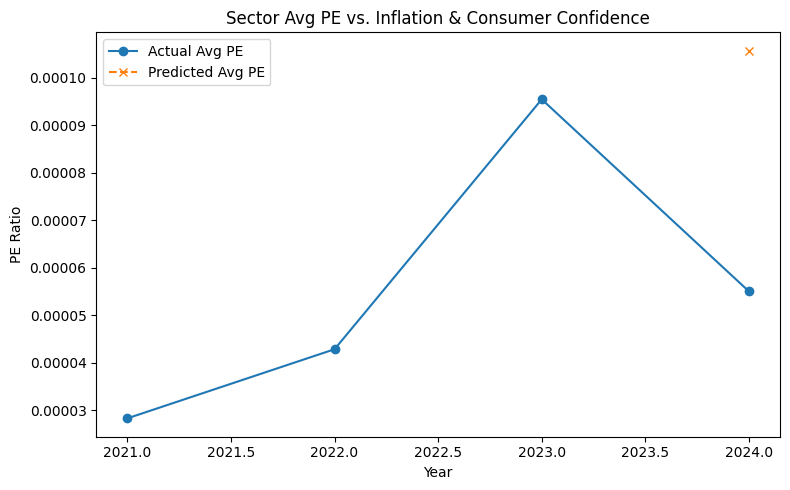

Regression Coefficients: {'Inflation': np.float64(-0.0018790696634618555), 'Cons_Conf': np.float64(-1.7089233665233123e-05)}
Intercept: 0.0001606952679488424
Confusion Matrix (up/down):
 []


In [287]:
# %%
# Merge macro data (year‑end % changes) and align to sector PE years

# Annual inflation (% change at year‑end)
inf_ann = (
    pdr.DataReader('CPIAUCSL', 'fred', start=pe_df.index.min())
       .resample('YE').last()
       .pct_change().dropna()
       .rename(columns={'CPIAUCSL': 'Inflation'})
)
inf_ann.index = inf_ann.index.year

# Annual consumer confidence (% change at year‑end)
cconf = (
    pdr.DataReader('UMCSENT', 'fred', start=pe_df.index.min())
       .resample('YE').last()
       .pct_change().dropna()
       .rename(columns={'UMCSENT': 'Cons_Conf'})
)
cconf.index = cconf.index.year

# Combine macro series and keep only years present in pe_df
macro = pd.concat([inf_ann, cconf], axis=1).dropna()
common_years = macro.index.intersection(pe_df.index)
macro = macro.loc[common_years]

# Slice sector average PE to those same years
pe_sub = pe_df['Average_PE'].loc[common_years]

# Multiple Linear Regression: Average_PE ~ Inflation + Consumer Confidence
X2 = macro[['Inflation', 'Cons_Conf']].values
y2 = pe_sub.values
X2tr, X2te, y2tr, y2te = train_test_split(X2, y2, test_size=0.25, shuffle=False)

mlr = LinearRegression().fit(X2tr, y2tr)
y2pred = mlr.predict(X2te)

# Plot actual vs. predicted average PE
plt.figure(figsize=(8, 5))
plt.plot(common_years,    pe_sub,   marker='o', label='Actual Avg PE')
plt.plot(common_years[-len(y2te):], y2pred,
         marker='x', linestyle='--', label='Predicted Avg PE')
plt.xlabel('Year')
plt.ylabel('PE Ratio')
plt.title('Sector Avg PE vs. Inflation & Consumer Confidence')
plt.legend()
plt.tight_layout()
plt.show()

# Confusion matrix for directional accuracy (up/down)
y2te_up   = (y2te[1:] > y2te[:-1]).astype(int)
y2pred_up = (y2pred[1:] > y2pred[:-1]).astype(int)
cm = confusion_matrix(y2te_up, y2pred_up)

print("Regression Coefficients:", dict(zip(['Inflation','Cons_Conf'], mlr.coef_)))
print("Intercept:", mlr.intercept_)
print("Confusion Matrix (up/down):\n", cm)


# Question 3: Hypothesis Test with Unemployment

Test whether changes in the unemployment rate correlate with the sector’s average PE. We perform a simple linear regression with annual ΔUnemployment as predictor.


Unemployment coefficient: 9.584354491855225e-05
Intercept: 6.392866515222251e-05
R²: 0.6151667161394194


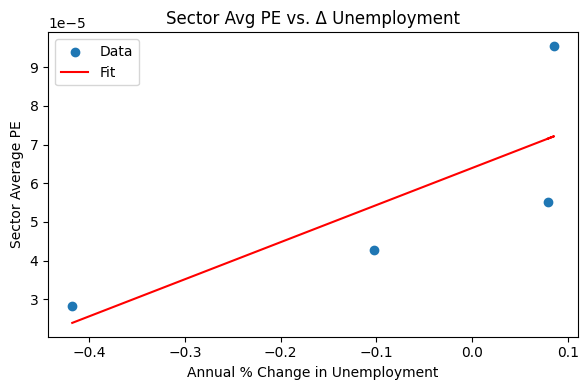

In [288]:
# %%
# Question 3: Hypothesis Test with Unemployment

# Annual unemployment rate change (year‑end % change)
unemp = (
    pdr.DataReader('UNRATE', 'fred', start=pe_df.index.min())
       .resample('YE').last()
       .pct_change()
       .dropna()
       .rename(columns={'UNRATE': 'Unemployment'})
)
unemp.index = unemp.index.year

# Combine inflation, consumer confidence, and unemployment into macro2
macro2 = pd.concat([inf_ann, cconf, unemp], axis=1).dropna()

# Restrict to years present in our sector PE DataFrame
common_years2 = macro2.index.intersection(pe_df.index)
macro2 = macro2.loc[common_years2]

# Slice sector average PE to those same years
pe_sub2 = pe_df['Average_PE'].loc[common_years2]

# Simple linear regression: Avg_PE ~ Unemployment
X3 = macro2[['Unemployment']].values
y3 = pe_sub2.values
lr3 = LinearRegression().fit(X3, y3)

# Print model metrics
print("Unemployment coefficient:", lr3.coef_[0])
print("Intercept:", lr3.intercept_)
print("R²:", lr3.score(X3, y3))

# Plot the relationship
plt.figure(figsize=(6, 4))
plt.scatter(macro2['Unemployment'], y3, label='Data')
plt.plot(macro2['Unemployment'], lr3.predict(X3), c='red', label='Fit')
plt.xlabel('Annual % Change in Unemployment')
plt.ylabel('Sector Average PE')
plt.title('Sector Avg PE vs. Δ Unemployment')
plt.legend()
plt.tight_layout()
plt.show()


# Question 4: Model Comparison on MSFT Price

Compare LinearRegression, PolynomialRegression (degree 3), and RandomForest in fitting MSFT closing prices. Plot actual vs. predictions, and forecast the closing price for June 1, 2025.


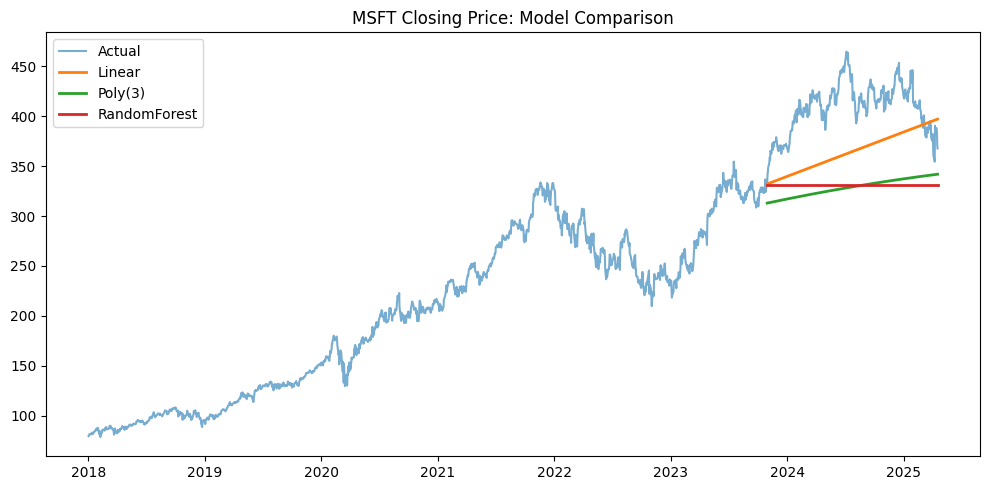

Predictions for 2025‑06‑01:
 LinearReg:    402.7020130956371
 Poly(3):      343.7344720168039
 RandomForest: 330.9504428100586


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [289]:
# %%
# Fetch MSFT history and prepare features
msft_hist = yf.Ticker('MSFT').history(start='2018-01-01',
                                       end=datetime.today().strftime('%Y-%m-%d'))
msft_hist['DateOrd'] = msft_hist.index.map(datetime.toordinal)
X4 = msft_hist[['DateOrd']]
y4 = msft_hist['Close']

# Train/test split
X4tr, X4te, y4tr, y4te = train_test_split(X4, y4, test_size=0.2, shuffle=False)

# Linear Regression
lr4 = LinearRegression().fit(X4tr, y4tr)
pred_lr = lr4.predict(X4te)

# Polynomial Regression (degree=3)
pf = PolynomialFeatures(3)
Xp4   = pf.fit_transform(X4tr)
Xp4te = pf.transform(X4te)
pr = LinearRegression().fit(Xp4, y4tr)
pred_pr = pr.predict(Xp4te)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=0).fit(X4tr, y4tr)
pred_rf = rf.predict(X4te)

# Plot actual vs. models
plt.figure(figsize=(10,5))
plt.plot(msft_hist.index, y4, label='Actual', alpha=0.6)
plt.plot(X4te.index, pred_lr, label='Linear', linewidth=2)
plt.plot(X4te.index, pred_pr, label='Poly(3)', linewidth=2)
plt.plot(X4te.index, pred_rf, label='RandomForest', linewidth=2)
plt.legend()
plt.title('MSFT Closing Price: Model Comparison')
plt.tight_layout()
plt.show()

# Forecast for June 1, 2025
future_ord = datetime(2025,6,1).toordinal()
print("Predictions for 2025‑06‑01:")
print(" LinearReg:   ", lr4.predict([[future_ord]])[0])
print(" Poly(3):     ", pr.predict(pf.transform([[future_ord]]))[0])
print(" RandomForest:", rf.predict([[future_ord]])[0])


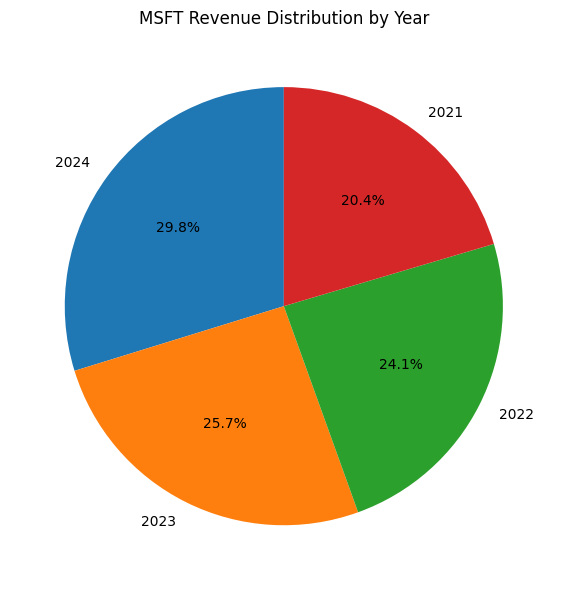

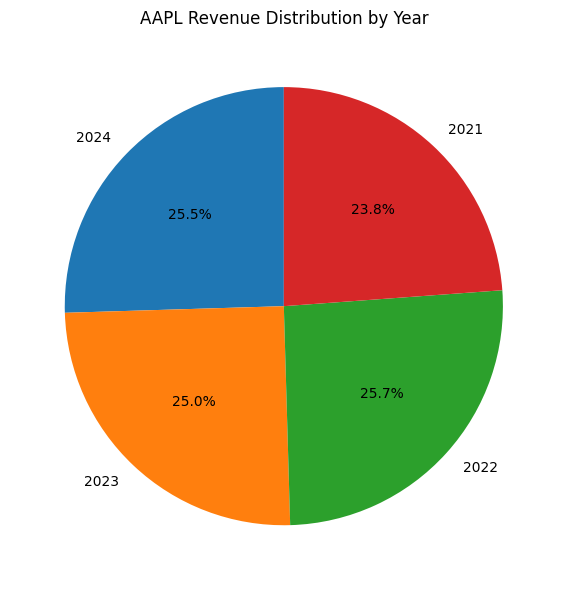

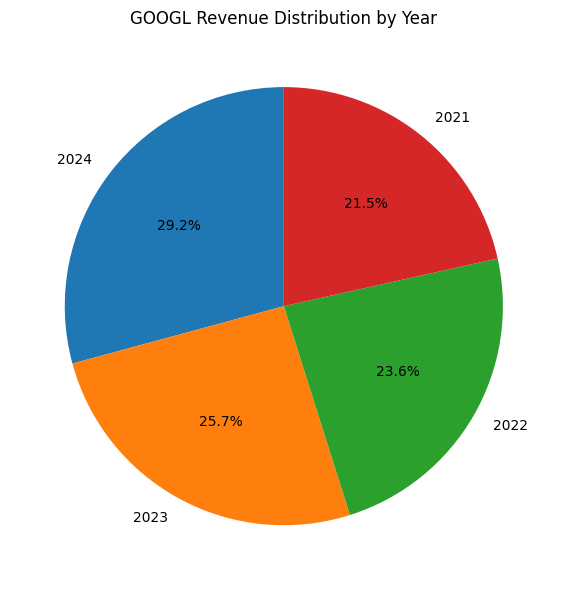

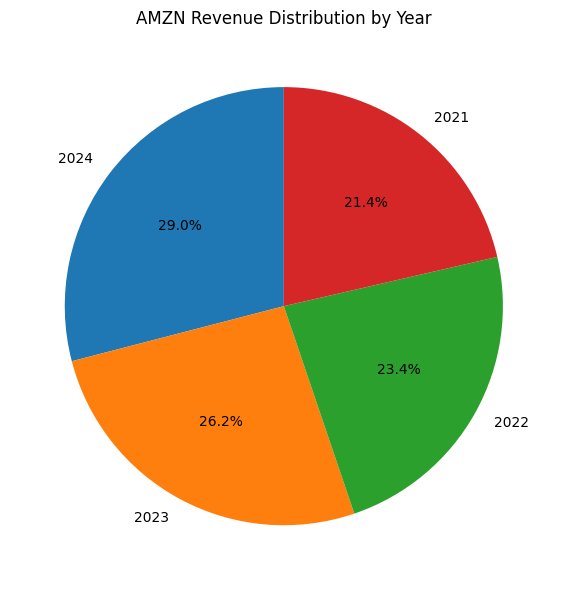

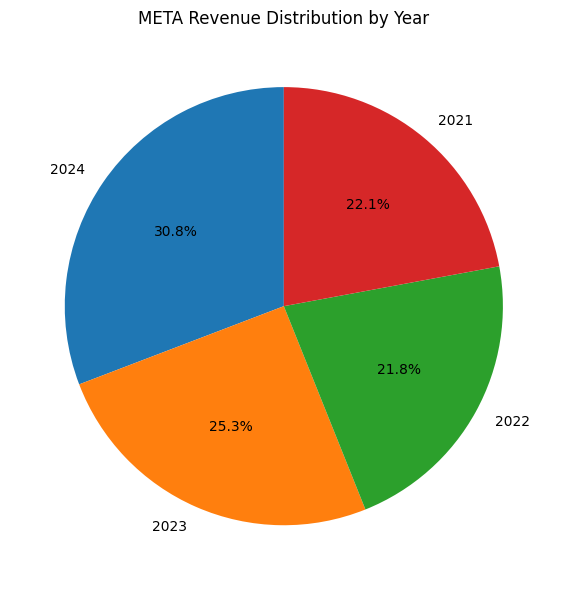

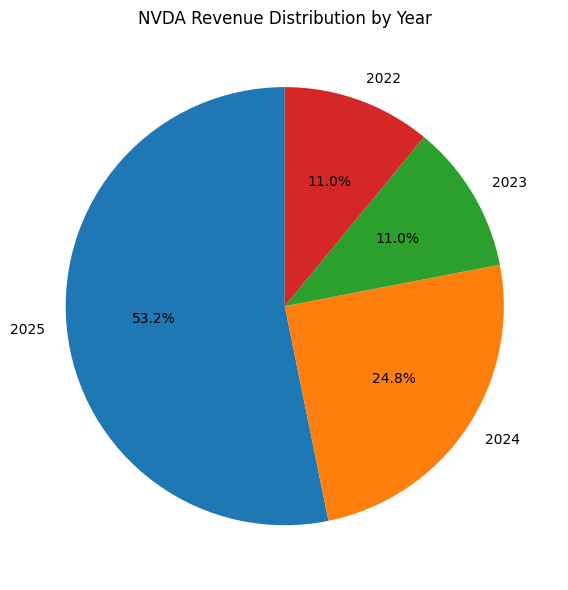

In [290]:
# %%
# Q3 (pie charts): Revenue distribution by year for all 6 stocks
for sym, df in [('MSFT', msft_df)] + [(t, peer_data[t]) for t in peer_tickers]:
    plot_revenue_pie(sym, df)

# Conclusion

- **Q1:** Interpret the R² and slope from the MSFT earnings vs. inflation regression.  
- **Q1‑b:** Compare R² when increasing training size from 50 % to 75 %.  
- **Q2:** Examine regression coefficients on inflation and consumer confidence, and review the up/down confusion matrix.  
- **Q3:** Assess whether ΔUnemployment significantly predicts sector average PE.  
- **Q4:** Compare the three model fits visually and discuss each model’s forecast for June 1, 2025.
